# Butterfly CNN Classification

> This project was originally completed as part of university coursework and has been reorganised and documented for professional portfolio presentation.

## Notebook scope

This notebook develops and evaluates a compact convolutional neural network for five-class butterfly image classification. The course-provided images are not distributed in this repository because redistribution permission has not been confirmed.

## Dependencies

Python, NumPy, Pandas, OpenCV, Matplotlib, PyTorch and Torchvision are required. Set the `BUTTERFLY_DATA_DIR` environment variable to a lawful local copy of the dataset; otherwise the notebook looks for `data/raw/` within this project.

## Verified evaluation context

The reported **72.22% accuracy** was measured on an internal 18-image split. It was not measured on the separately supplied 30-image external test set. The cleaned dataset is severely imbalanced: Mourning Cloak 38, Sleepy Orange 37, Atala 35, Sootywing 2 and Gold Banded 1.


In [ ]:
from pathlib import Path
import os
import random
import numpy as np
import torch

SEED = 1978974
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

working_directory = Path.cwd().resolve()
project_directory = working_directory.parent if working_directory.name == "notebooks" else working_directory
data_root = Path(os.environ.get("BUTTERFLY_DATA_DIR", project_directory / "data" / "raw"))
train_csv = data_root / "Train_label.csv"
test_csv = data_root / "Test_label.csv"
train_dir = data_root / "train"
processed_dir = data_root / "processed"
cleaned_csv = processed_dir / "train-labels-cleaned.csv"

required_paths = [train_csv, test_csv, train_dir]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Butterfly data is not included. Set BUTTERFLY_DATA_DIR to a lawful local dataset copy. "
        f"Missing: {missing_paths}"
    )


# Task 0: Data Visualization

Samples of the train data:
         filename           label
0   Image_292.jpg   SLEEPY ORANGE
1   Image_373.jpg   SLEEPY ORANGE
2   Image_251.jpg  MOURNING CLOAK
3   Image_998.jpg   SLEEPY ORANGE
4  Image_1220.jpg  MOURNING CLOAK

Label distribution in training data:
label
MOURNING CLOAK    39
SLEEPY ORANGE     38
ATALA             37
?                  3
SOOTYWING          2
GOLD BANDED        1
Name: count, dtype: int64


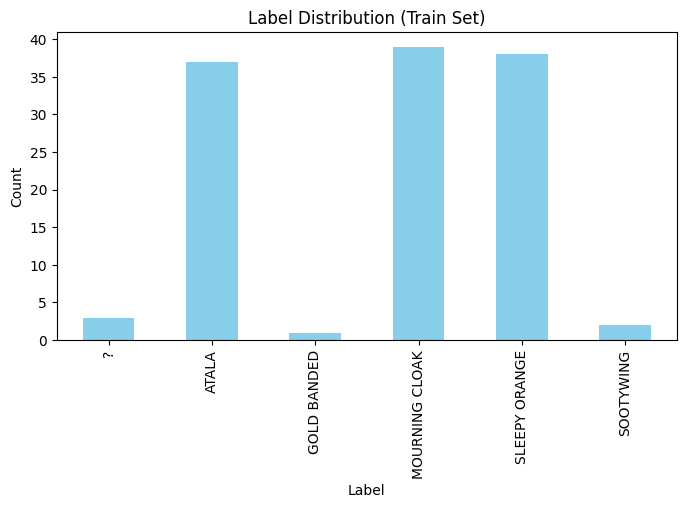

In [ ]:
# First, it is a pre-requisite to load the data for visualization. There are two types of dat her. One is image and other one is csv file. So, the data should be loaded first.
# To check the data is loaded, printing the head is enough for the csv file. And a few sample images should be print as well.
# Then need to sort the labels sothat we can understand hou many lebels are there and is there any NA or unidentified lebel.
# Then we need to know the frequency of the lebel. It will be better to plot a graph for the visualization.


import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# Dataset paths are configured in the setup cell.

# Reading the CSV files
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# Showing first few rows
print("Samples of the train data:")
print(train_df.head())

# Showing the label names
print("\nLabel distribution in training data:")
print(train_df['label'].value_counts())

# Ploting label for understanding the frequency
plt.figure(figsize=(8,4))
train_df['label'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Label Distribution (Train Set)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Display few random sample images
print("\nShowing 5 sample images:")
sample = train_df.sample(5, random_state=42)

for idx, row in sample.iterrows():
    img_path = os.path.join(train_dir, row['filename'])
    img = cv2.imread(img_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"Label: {row['label']}")
        plt.axis('off')
        plt.show()
    else:
        print(f"Image not found: {row['filename']}")


# Task 1: Data Preprocessing

### 1.1 Data Cleaning (2%)

In [ ]:

# Non-destructive data cleaning
import numpy as np

train_df = pd.read_csv(train_csv)
print("Before cleaning:", train_df.shape)
print("Missing values in each column:\n", train_df.isna().sum())

clean_df = train_df[train_df["label"].notna() & (train_df["label"] != "?")].copy()

def is_black_or_unreadable(image_path, threshold=5):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return True
    return np.mean(image < threshold) > 0.99

bad_images = [
    row["filename"]
    for _, row in clean_df.iterrows()
    if not (train_dir / row["filename"]).exists()
    or is_black_or_unreadable(train_dir / row["filename"])
]

clean_df = clean_df[~clean_df["filename"].isin(bad_images)].reset_index(drop=True)
processed_dir.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(cleaned_csv, index=False)

print("After non-destructive cleaning:", clean_df.shape)
print(clean_df["label"].value_counts())
print(f"Cleaned annotations written to: {cleaned_csv}")
print("No source images were deleted or modified.")


### 1.2 Data Processing (2%)

In [ ]:
# In this case, first need to need to read the cleaned dataset
# Then resizing them to 64x64 pixels
# Also normalize pixel values to [0, 1].


# Load the annotations created by the non-destructive cleaning step.
train_df = pd.read_csv(cleaned_csv)
print("Loaded cleaned dataset:", train_df.shape)


# Lists to store processed image data and labels
images = []
labels = []


# Convert text labels (e.g., "MONARCH") into numeric values for training
unique_labels = sorted(train_df['label'].unique())
label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
print("Label to ID mapping:", label_to_id)


IMG_SIZE = (64, 64)  # all images resized to this fixed dimension

for idx, row in train_df.iterrows():
    img_path = os.path.join(train_dir, row['filename'])
    
    # Read the image using OpenCV
    img = cv2.imread(img_path)
    if img is None:
        print(f" Skipping unreadable image: {row['filename']}")
        continue
    
    # Resize the image to 64x64 pixels
    img_resized = cv2.resize(img, IMG_SIZE)
    
    # Normalize pixel values to [0, 1] for better training stability
    img_normalized = img_resized / 255.0
    
    # Append the processed image and its numeric label
    images.append(img_normalized)
    labels.append(label_to_id[row['label']])


# Convert to arrays so they can be easily split and converted into PyTorch tensors
images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)

print("Processed images shape found:", images.shape)
print("Labels shape are:", labels.shape)
print("Pixel value range evaluation:", f"{images.min():.2f} to {images.max():.2f}")


Loaded cleaned dataset: (113, 2)
Label to ID mapping: {'ATALA': 0, 'GOLD BANDED': 1, 'MOURNING CLOAK': 2, 'SLEEPY ORANGE': 3, 'SOOTYWING': 4}
Processed images shape found: (113, 64, 64, 3)
Labels shape are: (113,)
Pixel value range evaluation: 0.00 to 1.00


In [ ]:
# It is found that there are 7 corrupted images which are removed and that datset is loaded. Then the labels are mapped through 0 to 4 accordingly. 
# Image is resized to 64*64 using .resize and the images are normalized in [0,1]. 

### 1.3 Data Split and Loader (2%)

In [ ]:
# The dataset should be ready for model training in this section.  In order to prepare the images and labels for CNN models, 
# they must first be transformed into PyTorch tensors and reshaped using the channel-first format (N, C, H, W).  
# After combining the data into a TensorDataset, it should be divided into subsets for training (70%), validation (15%), and testing (15%).  
# The random_split function guarantees non-overlapping partitions and reproducible results by using a fixed random seed, in this case my student ID. 
# Lastly, to effectively handle data loading, batching, and shuffling during training and assessment, DataLoader objects needed to be developed.

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

# Convert images and labels into tensors for compatibility with PyTorch DataLoader
images_tensor = torch.tensor(images)   # shape: (num_samples, 64, 64, 3)
labels_tensor = torch.tensor(labels)

# Reorder dimensions from (N, H, W, C) → (N, C, H, W) for CNNs because PyTorch expects channel-first format
images_tensor = images_tensor.permute(0, 3, 1, 2)

print("Tensor shapes ->", images_tensor.shape, labels_tensor.shape)

# TensorDataset binds images and labels together for easy access
dataset = TensorDataset(images_tensor, labels_tensor)

# Split the dataset into Train (70%), Validation (15%), Test (15%)
total_size = len(dataset)
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
train_size = int(total_size * train_ratio)
val_size = int(total_size * val_ratio)
test_size = total_size - train_size - val_size  # ensures all samples are used

# random_split ensures there is no overlap between train/val/test sets
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(1978974)  # set seed for reproducibility
    ) 

print(f"Dataset sizes -> Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

# DataLoaders handle batching and shuffling automatically during training
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Fetch one batch to verify everything is working properly
sample_images, sample_labels = next(iter(train_loader))
print("Sample batch shape:", sample_images.shape)
print("Sample labels:", sample_labels[:10])  # show first few labels

print("\n I am ready!")


Tensor shapes -> torch.Size([113, 3, 64, 64]) torch.Size([113])
Dataset sizes -> Train: 79, Validation: 16, Test: 18
Sample batch shape: torch.Size([16, 3, 64, 64])
Sample labels: tensor([3, 2, 2, 3, 3, 3, 4, 2, 3, 2])

 I am ready!


### 1.4 Data Augmentation

In [ ]:
# To improve model generalization and avoid overfitting, the dataset should now be improved through data augmentation. 
# In order to increase image diversity without changing the essential content, basic transformations like random horizontal flips and rotations (±20°) are only applied to the training dataset in this section. 
# To guarantee an objective assessment of performance, the test and validation sets are kept constant.To ensure effective on-the-fly augmentation, 
# these transformations are applied dynamically when loading images using a custom ButterflyDataset class. 
# In order to give the model a variety of inputs throughout each training epoch, new DataLoader objects are then constructed using the augmented datasets.

import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset



train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),   # randomly flip images horizontally (50% chance)
    transforms.RandomRotation(degrees=20),    # randomly rotate images within ±20 degrees
])

val_test_transform = transforms.Compose([
    # Validation/Test: only tensor conversion, no random transformations
    transforms.Lambda(lambda x: x)            # identity transform (keeps images as they are)
])

# This class allows us to apply transforms to existing image tensors on the fly.
class ButterflyDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        # Convert image tensor back to NumPy for OpenCV-style transforms if needed
        image_np = image.permute(1, 2, 0).numpy()
        image_np = (image_np * 255).astype('uint8')

        # Convert to PIL image for torchvision transforms
        from PIL import Image
        image_pil = Image.fromarray(image_np)

        if self.transform:
            image_pil = self.transform(image_pil)

        # Convert back to tensor and normalize to [0,1]
        image_tensor = transforms.ToTensor()(image_pil)
        return image_tensor, label

# We apply augmentation only on training data to enhance diversity, while validation and test data stay clean for unbiased evaluation.

train_dataset_aug = ButterflyDataset(train_dataset, transform=train_transform)
val_dataset_noaug = ButterflyDataset(val_dataset, transform=val_test_transform)
test_dataset_noaug = ButterflyDataset(test_dataset, transform=val_test_transform)

# Rebuild DataLoaders so they use the augmented datasets.
train_loader = DataLoader(train_dataset_aug, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset_noaug, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset_noaug, batch_size=16, shuffle=False)

print("\n Wow ! I am successfully! ha ha ha")


# Task 2: Training Loop (7%)

### 2.1 Model Architecture (2%)

In [ ]:
# In this section, we will use only the most basic PyTorch layers to construct a basic Convolutional Neural Network (CNN).
# The objective is to develop a model that can recognize and accurately classify butterfly images by learning patterns like edges, colors, and shapes. 
# There will be three convolutional layers at the beginning of our network. The first one picks up basic features like edges, the second one records patterns and textures, 
# and the third one concentrates on more intricate details. Following every convolution, 
# we employ ReLU to add non-linearity and MaxPooling to minimize the image size while preserving crucial data.

import torch.nn as nn
import torch.nn.functional as F

# Defining the CNN Architecture
class ButterflyCNN(nn.Module):
    def __init__(self, num_classes):
        super(ButterflyCNN, self).__init__()

        # 1st Convolutional Layer: Extracts low-level features like edges, shapes, and colors
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial size (64→32, 32→16, etc.)

        # 2nd Convolutional Layer: Learns deeper features such as patterns or textures
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # 3rd Convolutional Layer: Extracts higher-level abstract features
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # flattened feature maps → hidden layer
        self.fc2 = nn.Linear(128, num_classes)  # hidden layer → class scores

    def forward(self, x):
        # Forward propagation: defines how data moves through the network
        x = self.pool(F.relu(self.conv1(x)))  # Conv1 + ReLU + Pool
        x = self.pool(F.relu(self.conv2(x)))  # Conv2 + ReLU + Pool
        x = self.pool(F.relu(self.conv3(x)))  # Conv3 + ReLU + Pool
        x = x.view(x.size(0), -1)             # Flatten for fully connected layers
        x = F.relu(self.fc1(x))               # Hidden layer activation
        x = self.fc2(x)                       # Output layer (raw class scores)
        return x

# Create model
# num_classes = total number of butterfly categories in your cleaned dataset
num_classes = len(label_to_id)
model = ButterflyCNN(num_classes)

# Display model summary
print(model)


ButterflyCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


### 2.2 Training Loop (5%)

In [ ]:
#In this section, we will train our CNN model to identify images of butterflies. We will use SGD and Adam optimizers with varying learning rates to test three different parameter settings. 
# We'll see which one functions the best. Following each batch, we will update the weights, compute the loss using CrossEntropyLoss, and train the model for five epochs. 
# To determine how well the model is learning, we will also examine the validation accuracy at the end of each epoch. In order to determine the final accuracy, we will lastly test the best model on the test set.

import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Defining the loss function and CrossEntropyLoss 
criterion = nn.CrossEntropyLoss()

# Define parameter settings: We'll train the same model three times with different optimizers and learning rates

param_settings = [
    {"optimizer": "SGD",  "lr": 0.01,  "momentum": 0.9},
    {"optimizer": "Adam", "lr": 0.001},
    {"optimizer": "Adam", "lr": 0.0005}
]

# Defining a reusable training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    model.to(device)

    for epoch in range(epochs):
        model.train()  # put model in training mode
        running_loss, correct, total = 0.0, 0, 0

        # Training loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()               # clears previous gradients (critical step)
            outputs = model(images)             # forward pass
            loss = criterion(outputs, labels)    # compute loss
            loss.backward()                      # backpropagation (calculate gradients)
            optimizer.step()                     # update weights

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1) # get predicted classes
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation loop
        model.eval()  # evaluation mode disables dropout, etc.
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return model

# Train models with three parameter settings
best_model = None
best_val_acc = 0
best_params = None

for i, params in enumerate(param_settings, 1):
    print(f"\n Training Model {i} with parameters: {params}")
    
    model = ButterflyCNN(num_classes).to(device)
    
    if params["optimizer"] == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=params["lr"], momentum=params["momentum"])
    elif params["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    
    trained_model = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

    # Evaluate final validation accuracy to choose the best model
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    val_acc = 100 * val_correct / val_total

    print(f"Validation Accuracy for Model {i}: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = trained_model
        best_params = params

print(f"\n Best Model uses parameters: {best_params} with Validation Accuracy = {best_val_acc:.2f}%")

# Evaluate best model on test set
best_model.eval()
test_correct, test_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"\n Final Test Accuracy (Best Model): {test_acc:.2f}%")


# To find the best combination, we used three parameter settings to train the CNN model in this step. Due to their disparate strengths, 
# two optimizers—SGD and Adam—were used. Through the reduction of oscillations during weight updates, SGD with momentum (0.9)** offers steady and gradual learning. 
# Adam allows for quicker and more seamless convergence by automatically modifying the learning rate for every parameter. To find out which provides the best balance, 
# we tested Adam using learning rates of 0.001 and 0.0005.
# Gradient clearing with `optimizer.zero_grad()` is a crucial step in the training loop. This keeps gradients from earlier batches from building up, guaranteeing the accuracy of every update. 
# Forward pass, backward pass to compute gradients, loss calculation using `CrossEntropyLoss`, and parameter updates via the optimizer are the four main steps in the training process. 
# To monitor model improvement and identify overfitting, validation is carried out at the conclusion of each epoch.The same batch size and dataset split were used to train each model over five epochs. 

Using device: cpu

 Training Model 1 with parameters: {'optimizer': 'SGD', 'lr': 0.01, 'momentum': 0.9}
Epoch [1/5] | Train Loss: 1.5968 | Train Acc: 12.66% | Val Loss: 1.5505 | Val Acc: 37.50%
Epoch [2/5] | Train Loss: 1.5211 | Train Acc: 34.18% | Val Loss: 1.4046 | Val Acc: 37.50%
Epoch [3/5] | Train Loss: 1.3885 | Train Acc: 34.18% | Val Loss: 1.1760 | Val Acc: 37.50%
Epoch [4/5] | Train Loss: 1.2440 | Train Acc: 40.51% | Val Loss: 1.0826 | Val Acc: 37.50%
Epoch [5/5] | Train Loss: 1.2586 | Train Acc: 29.11% | Val Loss: 1.0757 | Val Acc: 62.50%
Validation Accuracy for Model 1: 62.50%

 Training Model 2 with parameters: {'optimizer': 'Adam', 'lr': 0.001}
Epoch [1/5] | Train Loss: 1.5048 | Train Acc: 24.05% | Val Loss: 1.2185 | Val Acc: 50.00%
Epoch [2/5] | Train Loss: 1.3129 | Train Acc: 36.71% | Val Loss: 1.0354 | Val Acc: 37.50%
Epoch [3/5] | Train Loss: 1.1861 | Train Acc: 54.43% | Val Loss: 0.8979 | Val Acc: 56.25%
Epoch [4/5] | Train Loss: 1.0622 | Train Acc: 55.70% | Val Loss: 

In [ ]:
# The best validation accuracy and consistent performance were attained by Adam, who had a learning rate of 0.001. Here, the assignment concludes. 

## Evaluation interpretation

Three optimiser configurations were compared using the same 79/16/18 internal train, validation and test split. Adam with a learning rate of 0.001 achieved the strongest recorded validation accuracy (93.75%) and produced 72.22% accuracy on the 18-image internal test split. The result is exploratory because the dataset is small and strongly imbalanced; it should not be interpreted as deployment-ready performance.
